In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# PostgreSQL connection
conn = psycopg2.connect(
    dbname="credit_card_project",
    user="postgres",
    password="Sneha@40",  
    host="localhost",
    port="5432"
)

In [3]:
# 2. Load Data into Pandas
customers_df = pd.read_sql("SELECT * FROM customers;", conn)
credit_df = pd.read_sql("SELECT * FROM credit_history;", conn)
transactions_df = pd.read_sql("SELECT * FROM transactions;", conn)
marketing_df = pd.read_sql("SELECT * FROM marketing_response;", conn)

C:\Users\Sneha\AppData\Local\Temp\ipykernel_14260\358849700.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers_df = pd.read_sql("SELECT * FROM customers;", conn)
C:\Users\Sneha\AppData\Local\Temp\ipykernel_14260\358849700.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_df = pd.read_sql("SELECT * FROM credit_history;", conn)
C:\Users\Sneha\AppData\Local\Temp\ipykernel_14260\358849700.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_df = pd.read_sql("SELECT * FROM transactions;", conn)
C:

In [4]:
# Close connection after loading
conn.close()

In [7]:
customers_df.head()

,customer_id,age,income,occupation,region
0,1,44,80724.0,Engineer,West
1,2,41,121956.0,Teacher,North
2,3,40,118723.0,Doctor,East
3,4,46,108365.0,Business,South
4,5,41,34450.0,Student,North


In [8]:
credit_df.head()

,customer_id,credit_score,existing_cards,default_history
0,1,654,2,True
1,2,347,4,False
2,3,392,5,False
3,4,754,4,False
4,5,534,1,False


In [9]:
transactions_df.head()

,transaction_id,customer_id,monthly_spend
0,1,67,4781.0
1,2,109,3212.0
2,3,147,4248.0
3,4,194,3968.0
4,5,131,2460.0


In [10]:
marketing_df.head()

,customer_id,adopted
0,1,False
1,2,False
2,3,True
3,4,False
4,5,False


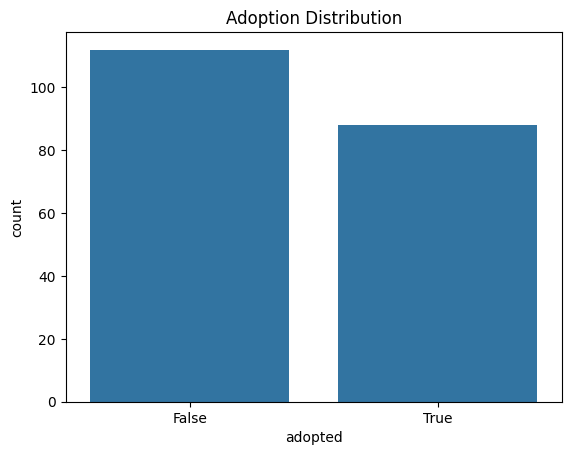

In [11]:
# Adoption distribution
sns.countplot(x="adopted", data=marketing_df)
plt.title("Adoption Distribution")
plt.show()

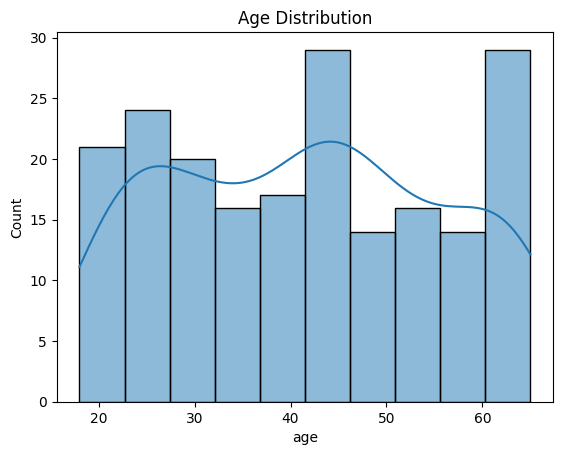

In [12]:
# Age distribution
sns.histplot(customers_df["age"], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

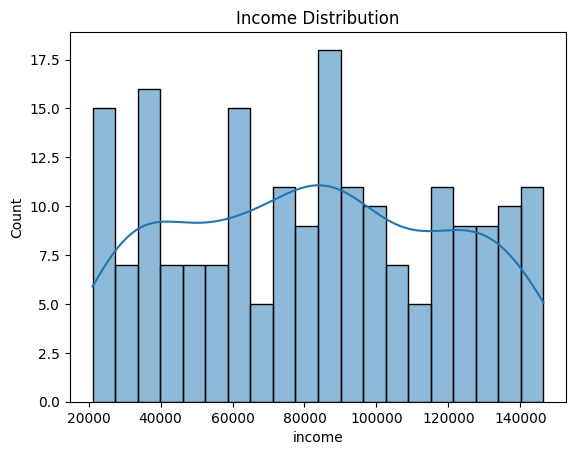

In [13]:
# Income distribution
sns.histplot(customers_df["income"], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

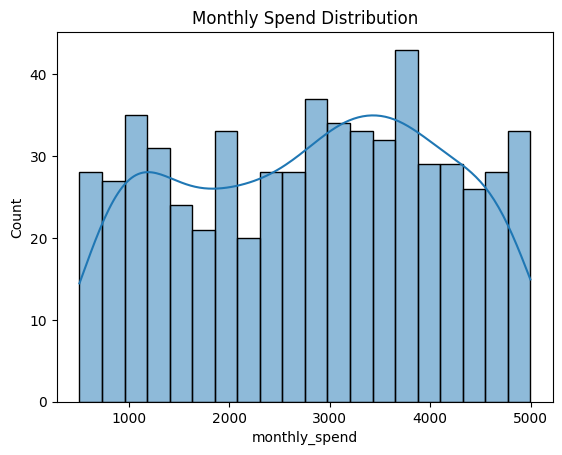

In [14]:
# Monthly spend distribution
sns.histplot(transactions_df["monthly_spend"], bins=20, kde=True)
plt.title("Monthly Spend Distribution")
plt.show()

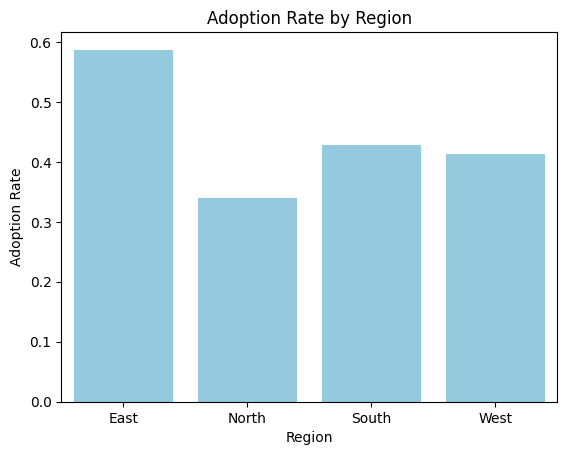

In [18]:
# Adoption rate by region
merged = customers_df.merge(marketing_df, on="customer_id")

adoption_by_region = merged.groupby("region")["adopted"].mean().reset_index()

sns.barplot(x="region", y="adopted", data=adoption_by_region, color="skyblue")
plt.title("Adoption Rate by Region")
plt.ylabel("Adoption Rate")
plt.xlabel("Region")
plt.show()

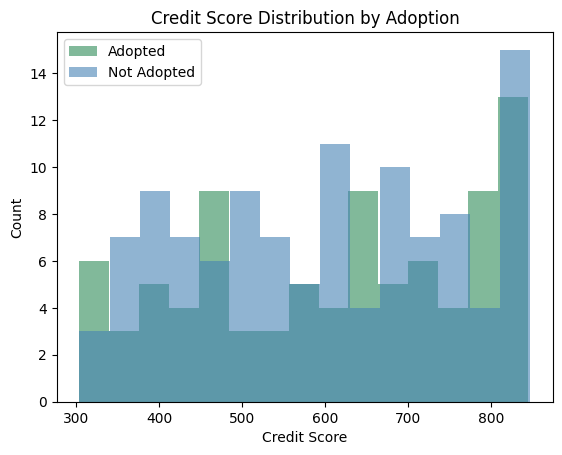

In [19]:
# Adoption vs Credit Score
adopted_scores = merged2[merged2["adopted"] == True]["credit_score"]
not_adopted_scores = merged2[merged2["adopted"] == False]["credit_score"]

plt.hist(adopted_scores, bins=15, alpha=0.6, color="seagreen", label="Adopted")
plt.hist(not_adopted_scores, bins=15, alpha=0.6, color="steelblue", label="Not Adopted")
plt.title("Credit Score Distribution by Adoption")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.legend()
plt.show()

### Feature Engineering

In [20]:
# Merge all tables into one dataset
df = customers_df.merge(credit_df, on="customer_id") \
                 .merge(transactions_df, on="customer_id") \
                 .merge(marketing_df, on="customer_id")

In [21]:
# Create income brackets
df["income_bracket"] = pd.cut(
    df["income"],
    bins=[0, 40000, 80000, df["income"].max()],
    labels=["Low Income", "Middle Income", "High Income"]
)

In [22]:
# Create credit score segments
df["credit_segment"] = pd.cut(
    df["credit_score"],
    bins=[0, 580, 669, 739, 799, df["credit_score"].max()],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)

In [23]:
# Average spend per customer 
df["avg_spend"] = df["monthly_spend"]

In [30]:
# One-hot encode occupation 
if "occupation" in df.columns:
    df = pd.get_dummies(df, columns=["occupation"], prefix="occ")

In [32]:
print(df.columns.tolist())

['customer_id', 'age', 'income', 'region', 'credit_score', 'existing_cards', 'default_history', 'transaction_id', 'monthly_spend', 'adopted', 'income_bracket', 'credit_segment', 'avg_spend', 'occ_Business', 'occ_Doctor', 'occ_Engineer', 'occ_Student', 'occ_Teacher']


In [35]:
# Adoption rate by income bracket
print(df.groupby("income_bracket",observed=True)["adopted"].mean().round(2))

# Adoption rate by credit segment
print(df.groupby("credit_segment",observed=True)["adopted"].mean().round(2))

# Average spend by adoption
print(df.groupby("adopted")["avg_spend"].mean().round(2))

income_bracket
Low Income       0.50
Middle Income    0.41
High Income      0.48
Name: adopted, dtype: float64
credit_segment
Poor         0.45
Fair         0.46
Good         0.39
Very Good    0.60
Excellent    0.46
Name: adopted, dtype: float64
adopted
False    2856.73
True     2756.66
Name: avg_spend, dtype: float64


### Simulation -  Impact of Increased Spend

In [44]:
#Current average spend by adopters vs non-adopters
current_spend = df.groupby("adopted")["avg_spend"].mean().round(2)
print("Current average spend:\n", current_spend)

Current average spend:
 adopted
False    2856.73
True     2756.66
Name: avg_spend, dtype: float64


In [45]:
# Scenario: adopters increase spend by 10%
df["simulated_spend"] = df.apply(
    lambda row: row["avg_spend"] * 1.10 if row["adopted"] else row["avg_spend"],
    axis=1
)

In [46]:
# Compare new average spend
simulated_spend = df.groupby("adopted")["simulated_spend"].mean().round(2)
print("\nSimulated average spend (10% increase for adopters):\n", simulated_spend)


Simulated average spend (10% increase for adopters):
 adopted
False    2856.73
True     3032.33
Name: simulated_spend, dtype: float64


In [47]:
# Total revenue impact
current_total = df["avg_spend"].sum().round(2)
simulated_total = df["simulated_spend"].sum().round(2)

In [48]:
print("\nCurrent total spend:", current_total)
print("Simulated total spend:", simulated_total)
print("Revenue increase:", simulated_total - current_total)


Current total spend: 1683261.0
Simulated total spend: 1760171.8
Revenue increase: 76910.80000000005


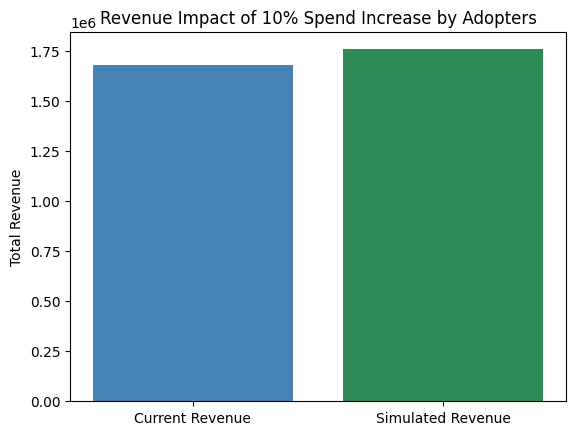

In [49]:
# 9. Visualization: Current vs Simulated Revenue

import matplotlib.pyplot as plt

# Values from simulation
values = [current_total, simulated_total]
labels = ["Current Revenue", "Simulated Revenue"]

# Bar chart
plt.bar(labels, values, color=["steelblue", "seagreen"])
plt.title("Revenue Impact of 10% Spend Increase by Adopters")
plt.ylabel("Total Revenue")
plt.show()


In [51]:
df.to_csv("merged.csv", index=False)